# Experiment 5: Test effect of batch norm

We'll now test the performance of CNNs with and without batch normalization. We'll again test on three datasets, MNIST, Fashion-MNIST, and CIFAR-10.

#### Change in validation accuracy from batch norm

* MNIST: 99.0 -> 98.9
* Fashion-MNIST: 90.1 -> 90.9
* CIFAR-10 validation accuracy: 65.5 -> 68.2

### Imports and setup

In [1]:
import os
import sys
notebook_dir = os.getcwd()
project_root = os.path.abspath(os.path.join(notebook_dir, '..', '..')) # Adjust as needed
if project_root not in sys.path:
    sys.path.append(project_root) # add notebook to sys.path

In [2]:
import torch
import matplotlib.pyplot as plt

from utils.train import fit, val_stats
from utils.hparams import CNNHyperParameters

In [3]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

Using mps device


### MNIST Experiments

In [4]:
hp = CNNHyperParameters(dataset='MNIST', id="MNIST CNN")
hp_bn = CNNHyperParameters(dataset='MNIST', batch_norm=True,
                           id="MNIST CNN w/ Batch Norm")

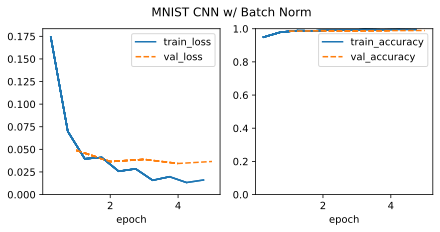

In [5]:
model = fit(hp, device=device)
model_bn = fit(hp_bn, device=device)

In [6]:
_, val_accuracy = val_stats(model, hp, device=device)
_, val_accuracy_bn = val_stats(model_bn, hp_bn, device=device)

In [7]:
print(f"Validation accuracy w/out batch norm: {val_accuracy:.3f}")
print(f"Validation accuracy w/ batch norm: {val_accuracy_bn:.3f}")

Validation accuracy w/out batch norm: 0.990
Validation accuracy w/ batch norm: 0.989


### Fashion-MNIST Experiments

In [8]:
hp = CNNHyperParameters(dataset='FashionMNIST', id="Fashion-MNIST CNN")
hp_bn = CNNHyperParameters(dataset='FashionMNIST', batch_norm=True,
                           id="Fashion-MNIST CNN w/ Batch Norm")

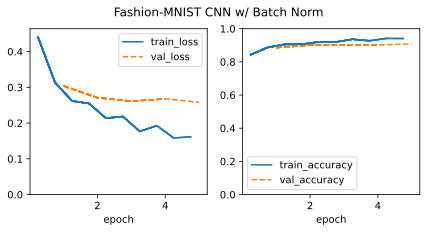

In [9]:
model = fit(hp, device=device)
model_bn = fit(hp_bn, device=device)

In [10]:
_, val_accuracy = val_stats(model, hp, device=device)
_, val_accuracy_bn = val_stats(model_bn, hp_bn, device=device)

In [11]:
print(f"Validation accuracy w/out batch norm: {val_accuracy:.3f}")
print(f"Validation accuracy w/ batch norm: {val_accuracy_bn:.3f}")

Validation accuracy w/out batch norm: 0.901
Validation accuracy w/ batch norm: 0.909


### CIFAR-10 Experiments

In [12]:
hp = CNNHyperParameters(dataset='CIFAR10', id="CIFAR-10 CNN")
hp_bn = CNNHyperParameters(dataset='CIFAR10', batch_norm=True,
                           id="CIFAR-10 CNN w/ Batch Norm")

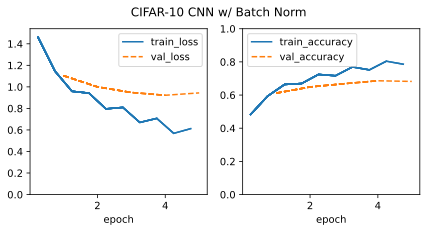

In [13]:
model = fit(hp, device=device)
model_bn = fit(hp_bn, device=device)

In [14]:
_, val_accuracy = val_stats(model, hp, device=device)
_, val_accuracy_bn = val_stats(model_bn, hp_bn, device=device)

In [15]:
print(f"Validation accuracy w/out batch norm: {val_accuracy:.3f}")
print(f"Validation accuracy w/ batch norm: {val_accuracy_bn:.3f}")

Validation accuracy w/out batch norm: 0.655
Validation accuracy w/ batch norm: 0.682
